# Figures and table for the paper, from the logged benchmark run

Reads the CSV files written by `overnight.jl` (in `results/`) and produces:

1. `InvGFTpanels.pdf` — the three-panel figure (convergence histories and rate validation);
2. the LaTeX rows of Table 1, printed for pasting into the manuscript;
3. the warm-start and tolerance-sensitivity numbers quoted in the text.

Requirements: a Julia kernel ([IJulia](https://github.com/JuliaLang/IJulia.jl): `using Pkg; Pkg.add("IJulia")`) and Plots.jl (`Pkg.add("Plots")`). Everything else is standard library. Run `overnight.jl` first.

In [1]:
using Plots, Printf, Statistics, LaTeXStrings
gr()

# minimal CSV reader: returns Vector{Dict{String,String}}
function readcsv(path)
    lines = readlines(path)
    hdr = split(lines[1], ',')
    [Dict(String(h) => String(v) for (h, v) in zip(hdr, split(l, ',')))
     for l in lines[2:end]]
end

res = "results/"
hist_rows = readcsv(res * "hist.csv")
rate_rows = readcsv(res * "rate.csv")
table_rows = readcsv(res * "table.csv")
warm_rows = readcsv(res * "warm.csv")
tol_rows  = readcsv(res * "tol.csv")
length.((hist_rows, rate_rows, table_rows, warm_rows, tol_rows))

(1696, 1000, 46, 30, 8)

## Figure: convergence histories (a, b) and rate validation (c)

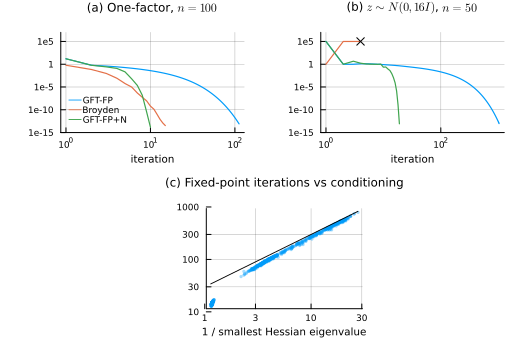

In [2]:
# organise histories: (panel, method) -> error path; convergence flags
hist = Dict{Tuple{String,String},Vector{Float64}}()
conv = Dict{Tuple{String,String},Bool}()
for r in hist_rows
    p, m = r["panel"], r["method"]
    if endswith(m, "_converged")
        conv[(p, m[1:end-10])] = r["err"] == "1"
    else
        push!(get!(hist, (p, m), Float64[]), min(parse(Float64, r["err"]), 1e5))
    end
end

methods = ["fp", "broyden", "fpn"]
labels  = Dict("fp" => "GFT-FP", "broyden" => "Broyden", "fpn" => "GFT-FP+N")
titles  = Dict("a" => L"(a) One-factor, $n = 100$", "b" => L"(b) $z \sim N(0, 16 I)$, $n = 50$")

function history_panel(p; legend = false)
    plt = plot(xscale = :log10, yscale = :log10,
               xlabel = "iteration", title = titles[p],
               ylims = (1e-15, 1e7),
               yticks = (10.0 .^ (-15:5:5),
                         ["1e-15", "1e-10", "1e-5", "1", "1e5"]),
               legend = legend ? :bottomleft : false,
               background_color_legend = :transparent,
               foreground_color_legend = :transparent,
               titlefontsize = 8, guidefontsize = 7, tickfontsize = 6,
               legendfontsize = 6, grid = true, gridalpha = 0.3)
    for (i, m) in enumerate(methods)
        h = hist[(p, m)]
        if !conv[(p, m)]
            k = findfirst(j -> j > 3 && h[j] > 1e3, eachindex(h))
            k === nothing || (h = h[1:k])
        end
        plot!(plt, 1:length(h), h, lw = 1.2, color = i, label = labels[m])
        if !conv[(p, m)]
            scatter!(plt, [length(h)], [h[end]], marker = :xcross, ms = 4,
                     msw = 1.5, color = :black, label = "")
        end
    end
    plt
end

pa = history_panel("a"; legend = true)
pb = history_panel("b")

lmin  = [parse(Float64, r["lmin"])  for r in rate_rows]
iters = [parse(Float64, r["iters"]) for r in rate_rows]
xg = 1 ./ lmin
pc = plot(xscale = :log10, yscale = :log10,
          xlabel = "1 / smallest Hessian eigenvalue",
          title = "(c) Fixed-point iterations vs conditioning",
          xticks = ([1, 3, 10, 30], ["1", "3", "10", "30"]),
          yticks = ([10, 30, 100, 300, 1000], ["10", "30", "100", "300", "1000"]),
          titlefontsize = 8, guidefontsize = 7, tickfontsize = 6,
          legend = false, grid = true, gridalpha = 0.3)
scatter!(pc, xg, iters, ms = 1.8, ma = 0.35, msw = 0)
gr_x = range(minimum(xg), maximum(xg); length = 50)
plot!(pc, gr_x, log(1e13) .* gr_x, lw = 0.9, color = :black)

blank() = plot(framestyle = :none, legend = false, grid = false)
l = @layout [a{0.5w} b{0.5w}; c{0.24w} d{0.52w} e{0.24w}]
fig = plot(pa, pb, blank(), pc, blank(), layout = l,
           size = (520, 350), margin = 2Plots.mm,
           left_margin = 5Plots.mm, top_margin = 3Plots.mm)
savefig(fig, "InvGFTpanels.pdf")
fig

## Table 1: LaTeX rows generated from `table.csv`

In [3]:
raised(x; digits = 2) = replace(digits == 1 ? @sprintf("%.1f", x) :
                                @sprintf("%.2f", x), "." => "{\\cdot}")

function fmt_time(t)
    t < 1 ? @sprintf("(%.0fms)", 1e3 * t) :
            "(\$" * raised(t; digits = 1) * "\$s)"
end

function fmt_cell(r; hv = false)
    med = parse(Float64, r["eighs_med"])
    isnan(med) && return "--\$^{" * r["fails"] * "}\$"
    fails = parse(Int, r["fails"])
    s = @sprintf("%.0f ", med)
    hv && (s *= "\\{" * @sprintf("%.0f", parse(Float64, r["hv_med"])) * "\\} ")
    s *= fmt_time(parse(Float64, r["time_med"]))
    fails > 0 && (s *= "\$^{" * string(fails) * "}\$")
    s
end

designs = [
    ("toeplitz_rho0.5_n100",  "Toeplitz \$\\rho=0{\\cdot}5\$, \$n=100\$"),
    ("toeplitz_rho0.9_n100",  "Toeplitz \$\\rho=0{\\cdot}9\$, \$n=100\$"),
    ("toeplitz_rho0.99_n100", "Toeplitz \$\\rho=0{\\cdot}99\$, \$n=100\$"),
    ("toeplitz_rho0.99_n300", "Toeplitz \$\\rho=0{\\cdot}99\$, \$n=300\$"),
    ("wishart_n100",          "Wishart, \$n=100\$"),
    ("factor_n100",           "One-factor, \$n=100\$"),
    ("z_sd2.0_n50",           "\$z\\sim N(0,4I_d)\$, \$n=50\$"),
    ("z_sd4.0_n50",           "\$z\\sim N(0,16I_d)\$, \$n=50\$"),
    ("factor_n800",           "One-factor, \$n=800\$"),
]

bydes = Dict{String,Dict{String,Dict{String,String}}}()
for r in table_rows
    get!(bydes, r["design"], Dict{String,Dict{String,String}}())[r["method"]] = r
end

for (key, label) in designs
    d = bydes[key]
    fp = fmt_cell(d["fp"])
    br = haskey(d, "broyden") ? fmt_cell(d["broyden"]) : "--"
    # Table 1 full-Newton column = GFT-FP+N with the exact Hessian
    # ("newtonsafe"); "newton" is the published variant, Section 5.1.3
    ne = haskey(d, "newtonsafe") ? fmt_cell(d["newtonsafe"]) : "--"
    a1 = fmt_cell(d["fpn"]; hv = true)
    lm = parse(Float64, d["fp"]["one_minus_lmin"])
    lmc = isnan(lm) ? "--" : "\$" * raised(lm) * "\$"
    println(label, " & ", fp, " & ", br, " & ", ne, " & ", a1, " & ", lmc, "\\\\")
end

Toeplitz $\rho=0{\cdot}5$, $n=100$ & 15 (12ms) & 5 (10ms) & 5 (26ms) & 7 \{12\} (7ms) & $0{\cdot}16$\\
Toeplitz $\rho=0{\cdot}9$, $n=100$ & 41 (30ms) & 8 (12ms) & 6 (27ms) & 8 \{19\} (9ms) & $0{\cdot}55$\\
Toeplitz $\rho=0{\cdot}99$, $n=100$ & 89 (66ms) & 8 (12ms) & 7 (34ms) & 9 \{25\} (10ms) & $0{\cdot}77$\\
Toeplitz $\rho=0{\cdot}99$, $n=300$ & 89 (645ms) & 8 (396ms) & -- & 9 \{26\} (130ms) & $0{\cdot}77$\\
Wishart, $n=100$ & 15 (11ms) & 6 (10ms) & 6 (31ms) & 7 \{12\} (7ms) & $0{\cdot}13$\\
One-factor, $n=100$ & 124 (131ms) & 16 (22ms) & 7 (33ms) & 10 \{27\} (14ms) & $0{\cdot}79$\\
$z\sim N(0,4I_d)$, $n=50$ & 473 (85ms) & 38 (7ms)$^{56}$ & 13 (5ms) & 17 \{64\} (4ms) & $0{\cdot}94$\\
$z\sim N(0,16I_d)$, $n=50$ & 1008 (181ms) & 52 (10ms)$^{978}$ & 18 (6ms) & 23 \{87\} (6ms) & $0{\cdot}97$\\
One-factor, $n=800$ & 136 ($15{\cdot}4$s) & -- & -- & 11 \{28\} ($2{\cdot}4$s)$^{1}$ & --\\


In [4]:
# Table 4 rows (Section 5.1.3): Newton as published | full Newton | GFT-FP+N,
# from table.csv, n <= 100 designs
function fmt_short(r)
    med = parse(Float64, r["eighs_med"]); fails = parse(Int, r["fails"])
    s = @sprintf("%.0f (%.0f)", med, 1e3 * parse(Float64, r["time_med"]))
    fails > 0 && (s *= "\$^{" * string(fails) * "}\$")
    s
end
for (key, label) in designs
    d = bydes[key]
    haskey(d, "newtonsafe") || continue
    println(label, " & ", fmt_short(d["newton"]), " & ", fmt_short(d["newtonsafe"]),
            " & ", fmt_short(d["fpn"]), "\\\\")
end


Toeplitz $\rho=0{\cdot}5$, $n=100$ & 5 (21) & 5 (26) & 7 (7)\\
Toeplitz $\rho=0{\cdot}9$, $n=100$ & 6 (27) & 6 (27) & 8 (9)\\
Toeplitz $\rho=0{\cdot}99$, $n=100$ & 7 (34) & 7 (34) & 9 (10)\\
Wishart, $n=100$ & 5 (20)$^{140}$ & 6 (31) & 7 (7)\\
One-factor, $n=100$ & 7 (34)$^{63}$ & 7 (33) & 10 (14)\\
$z\sim N(0,4I_d)$, $n=50$ & 14 (6)$^{82}$ & 13 (5) & 17 (4)\\
$z\sim N(0,16I_d)$, $n=50$ & 24 (8)$^{94}$ & 18 (6) & 23 (6)\\


## Numbers quoted in the text

In [5]:
# warm starts: mean over the 10 sequences of eighs per step
for m in ("fpn", "broyden", "fp")
    v = [parse(Float64, r["eighs_per_step"]) for r in warm_rows if r["method"] == m]
    @printf("warm-start %-8s eighs/step = %.1f\n", m, mean(v))
end
println()
# tolerance sensitivity
for r in tol_rows
    @printf("tol=%-7s %-8s median eighs = %-6s fails = %s/%s\n",
            r["tol"], r["method"], r["eighs_med"], r["fails"], r["total"])
end
println()
# headline speedups from unrounded medians
t(d, m) = parse(Float64, bydes[d][m]["time_med"])
@printf("speedup vs fixed point, sigma=4 design: %.1f\n",
        t("z_sd4.0_n50", "fp") / t("z_sd4.0_n50", "fpn"))
@printf("speedup vs fixed point, n=800:          %.1f\n",
        t("factor_n800", "fp") / t("factor_n800", "fpn"))
@printf("speedup vs Broyden, Toeplitz n=300:     %.1f\n",
        t("toeplitz_rho0.99_n300", "broyden") / t("toeplitz_rho0.99_n300", "fpn"))

warm-start fpn      eighs/step = 6.1
warm-start broyden  eighs/step = 6.2
warm-start fp       eighs/step = 103.2

tol=1.0e-6  fp       median eighs = 440.5  fails = 0/1000
tol=1.0e-6  broyden  median eighs = 35.0   fails = 978/1000
tol=1.0e-6  newton   median eighs = 21.0   fails = 0/1000
tol=1.0e-6  fpn      median eighs = 21.0   fails = 0/1000
tol=1.0e-13 fp       median eighs = 1007.5 fails = 0/1000
tol=1.0e-13 broyden  median eighs = 52.0   fails = 978/1000
tol=1.0e-13 newton   median eighs = 24.0   fails = 94/1000
tol=1.0e-13 fpn      median eighs = 23.0   fails = 0/1000

speedup vs fixed point, sigma=4 design: 31.0
speedup vs fixed point, n=800:          6.3
speedup vs Broyden, Toeplitz n=300:     3.1


Notes. The figure is written to `InvGFTpanels.pdf`, which the manuscript includes directly; it is sized to the journal text width (5.2 by 3.5 inches). The y-axis label of panel (a) is set in words here because the manuscript caption carries the mathematical definition. If Plots.jl chooses a different default font, the figure remains within the required dimensions since the canvas size is fixed.